## Lecture 1

### Environment Setup

The course installs PyTorch from a Linux CUDA wheel on a remote Ubuntu
server (`python3 -m pip install https://download.pytorch.org/whl/cu100/...`).
None of that applies here -- macOS has no `cu100` wheel, and the `ai-ml-ds`
kernel already has a matching torch/torchvision installed with Apple's Metal
(`mps`) GPU backend instead of CUDA -- so those install cells are replaced
with a simple version/device check.

In [1]:
import sys
print(sys.version)

3.12.13 (main, Mar  3 2026, 12:39:30) [Clang 17.0.0 (clang-1700.6.4.2)]


In [2]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)
print(torch.backends.mps.is_available())

2.13.0
0.28.0
True


### Bonus Tip

**Jupyter Notebook Remote Server**

*Terminal Only*

```
$ jupyter notebook --port 8888 --no-browser --ip 0.0.0.0
```

**Windows Troubleshooting**

Reference: [WINDOWS FAQ](https://jupyter-notebook.readthedocs.io/en/stable/troubleshooting.html)

### LeNet-5 Architecture

We define a class `LeNet5` that inherits from `torch.nn.Module`, and inside
the constructor we build the convolutional feature extractor as a
`torch.nn.Sequential` of three conv blocks (`Conv2d -> ReLU -> MaxPool2d`,
except the third block, whose output is already spatially `1x1` by the time
the last `Conv2d` runs, so there's nothing left to pool).

In [3]:
import torch


class LeNet5(torch.nn.Module):

    def __init__(self):

        super(LeNet5, self).__init__()

        self.convnet = torch.nn.Sequential(
            # Conv Block 1
            torch.nn.Conv2d(
                in_channels=1,
                out_channels=6,
                kernel_size=(5, 5),
                stride=1,
                bias=True
            ),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(
                kernel_size=(2, 2),
                stride=2
            ),
            # Conv Block 2
            torch.nn.Conv2d(
                in_channels=6,
                out_channels=16,
                kernel_size=(5, 5),
                stride=1,
                bias=True
            ),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(
                kernel_size=(2, 2),
                stride=2
            ),
            # Conv Block 3
            torch.nn.Conv2d(
                in_channels=16,
                out_channels=120,
                kernel_size=(5, 5),
                stride=1,
                bias=True
            ),
            torch.nn.ReLU(),
        )

        self.fcn = torch.nn.Sequential(
            # Fully Connected Layer 1
            torch.nn.Linear(
                in_features=120,
                out_features=84,
                bias=True
            ),
            torch.nn.ReLU(),
            # Classifier Layer 2
            torch.nn.Linear(
                in_features=84,
                out_features=10,
                bias=True
            ),
            torch.nn.Softmax(dim=1)
        )

    def forward(self, batch):
        ret = self.convnet(batch)
        ret = ret.view(batch.size(0), -1)
        ret = self.fcn(ret)
        return ret

### Visualize Network (Bonus)

Hint: visualization is very critical in implementing and debugging a deep
learning model.

**Note on `hiddenlayer`:** the course uses the `hiddenlayer` package here,
but that library hasn't been updated since 2019 and its PyTorch backend
calls `torch.onnx._optimize_trace`, an internal function that no longer
exists in modern PyTorch -- it raises `AttributeError` on import here
regardless of platform, not just on macOS. We use `torchviz` instead, which
renders the same kind of box-and-arrow computation graph via `graphviz`, but
traces through autograd rather than a now-removed ONNX export path, plus
`torchinfo` for a quick tabular summary (shapes and parameter counts per
layer) which is often the more useful view day-to-day.

In [4]:
try:
    import torchviz, torchinfo
except ImportError:
    # This kernel's venv is uv-managed and has no `pip` module, so plain
    # `python -m pip install` fails here. Fall back to `uv pip install`
    # (targeting this exact interpreter) when `pip` itself isn't available.
    import subprocess, sys
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'torchviz', 'torchinfo'])
    except Exception:
        subprocess.check_call(['uv', 'pip', 'install', '--python', sys.executable, 'torchviz', 'torchinfo'])

In [5]:
from torchinfo import summary

summary(LeNet5(), input_size=(1, 1, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
LeNet5                                   [1, 10]                   --
├─Sequential: 1-1                        [1, 120, 1, 1]            --
│    └─Conv2d: 2-1                       [1, 6, 28, 28]            156
│    └─ReLU: 2-2                         [1, 6, 28, 28]            --
│    └─MaxPool2d: 2-3                    [1, 6, 14, 14]            --
│    └─Conv2d: 2-4                       [1, 16, 10, 10]           2,416
│    └─ReLU: 2-5                         [1, 16, 10, 10]           --
│    └─MaxPool2d: 2-6                    [1, 16, 5, 5]             --
│    └─Conv2d: 2-7                       [1, 120, 1, 1]            48,120
│    └─ReLU: 2-8                         [1, 120, 1, 1]            --
├─Sequential: 1-2                        [1, 10]                   --
│    └─Linear: 2-9                       [1, 84]                   10,164
│    └─ReLU: 2-10                        [1, 84]                   --
│  

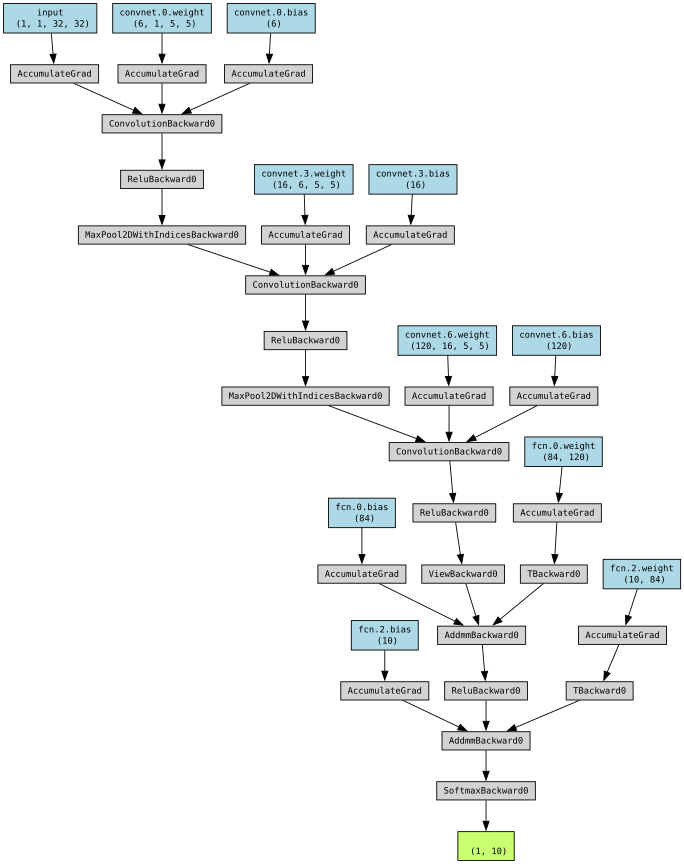

In [6]:
from torchviz import make_dot

model = LeNet5()
x = torch.zeros(1, 1, 32, 32, requires_grad=True)
y = model(x)

make_dot(y, params=dict(list(model.named_parameters()) + [('input', x)]))

Just implemented -- we can see it starts with a `5x5` convolution, `2x2`
pooling, on to another convolution of block, and it goes on: convolution,
pooling, convolution (no pooling, since the spatial size has already
shrunk to `1x1`), then a `Linear -> ReLU -> Linear -> Softmax` classifier
head, ending in the `10`-class output.